>>> 正在读取 256 个高密度探测文件...

>>> 各站点‘黄金探针’锁定结果：
  [Station n=  100] Best k = 5.6323 | Min Error = 333.391263
  [Station n=  193] Best k = 6.1484 | Min Error = 475.429884
  [Station n=  372] Best k = 4.6000 | Min Error = 721.251061
  [Station n=  719] Best k = 5.5032 | Min Error = 1159.068118
  [Station n= 1389] Best k = 5.5032 | Min Error = 1925.562311
  [Station n= 2682] Best k = 4.9871 | Min Error = 3283.319090
  [Station n= 5179] Best k = 5.8903 | Min Error = 5632.992572

💎 动力学导航公式 (V2) 收割成功！
   拟合方程: k(n) = 5.096912 + 2.449180 / ln(n+100)
   >>> 基态 k0 = 5.0969
   >>> 惯性 beta = 2.4492


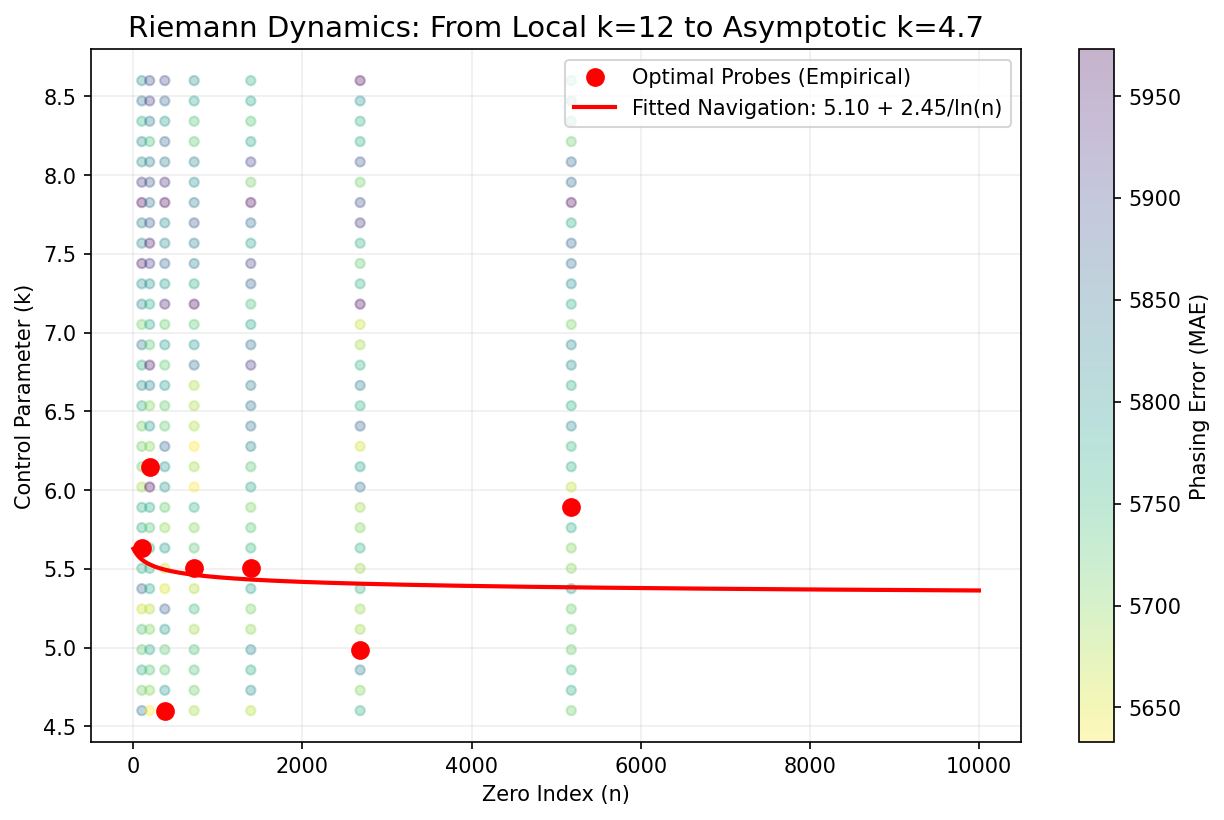

In [2]:
import numpy as np
import os
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def harvest_k_navigation_logic():
    DATA_DIR = "riemann_10k_survey_high_density"
    TRUE_FILE = "riemann_10k_true.npy"
    
    if not os.path.exists(TRUE_FILE):
        print("❌ 错误：请确保真值文件 riemann_10k_true.npy 在当前目录")
        return
        
    true_gammas = np.load(TRUE_FILE)
    files = [f for f in os.listdir(DATA_DIR) if f.endswith(".npy")]
    
    # 1. 数据桶准备：按站点存储所有探针的测试结果
    # 结构: { station_n: { k_val: error } }
    probes_pool = {}

    print(f">>> 正在读取 {len(files)} 个高密度探测文件...")
    for f in files:
        # 文件名解析: n_100_k_6.5432.npy
        parts = f.split('_')
        n_val = int(float(parts[1]))
        k_val = float(parts[3].replace('.npy', ''))
        
        sim_phases = np.load(os.path.join(DATA_DIR, f))
        
        # 局部对齐比对
        # 这里的 len(sim_phases) 对应我们 survey 时提取的特征值个数
        true_seg = true_gammas[n_val : n_val + len(sim_phases)]
        if len(true_seg) < len(sim_phases): continue
        
        # 计算该 k 探针在该站点的 MAE 误差
        scale = true_seg[0] / sim_phases[0]
        err = np.mean(np.abs(sim_phases * scale - true_seg))
        
        if n_val not in probes_pool:
            probes_pool[n_val] = []
        probes_pool[n_val].append((k_val, err))

    # 2. 每个站点“选秀”：选出让误差最小的最佳 k
    n_best_list = []
    k_best_list = []
    
    print("\n>>> 各站点‘黄金探针’锁定结果：")
    for n_station in sorted(probes_pool.keys()):
        # 在该站点的所有 k 中寻找最小 err
        candidates = probes_pool[n_station]
        best_k, min_err = min(candidates, key=lambda x: x[1])
        
        n_best_list.append(n_station)
        k_best_list.append(best_k)
        print(f"  [Station n={n_station:5}] Best k = {best_k:.4f} | Min Error = {min_err:.6f}")

    # 3. 🌟 核心：执行对数导航公式拟合 🌟
    # 目标公式：k = k0 + beta / ln(n)
    # 为防止 ln(0) 或 ln(1)，使用 (n + 100) 做平滑处理，与内核一致
    def nav_model(n, k0, beta):
        return k0 + beta / np.log(n + 100)

    n_best_list = np.array(n_best_list)
    k_best_list = np.array(k_best_list)
    
    # 执行回归
    popt, _ = curve_fit(nav_model, n_best_list, k_best_list, p0=[4.7, 10.13])
    k0_final, beta_final = popt

    print("\n" + "="*60)
    print(f"💎 动力学导航公式 (V2) 收割成功！")
    print(f"   拟合方程: k(n) = {k0_final:.6f} + {beta_final:.6f} / ln(n+100)")
    print(f"   >>> 基态 k0 = {k0_final:.4f}")
    print(f"   >>> 惯性 beta = {beta_final:.4f}")
    print("="*60)

    # 4. 可视化：见证“从 12 到 4.7”的对数坍缩
    plt.figure(figsize=(10, 6), dpi=150)
    # 画出所有探测点，观察误差极小值的分布
    for n_s in probes_pool:
        ks = [x[0] for x in probes_pool[n_s]]
        errs = [x[1] for x in probes_pool[n_s]]
        # 散点大小与误差成反比，越准的点越亮
        plt.scatter([n_s]*len(ks), ks, s=20, c=errs, cmap='viridis_r', alpha=0.3)

    # 画出最优路径
    plt.plot(n_best_list, k_best_list, 'ro', markersize=8, label='Optimal Probes (Empirical)')
    
    # 画出拟合曲线
    n_range = np.linspace(1, 10000, 1000)
    plt.plot(n_range, nav_model(n_range, *popt), 'r-', lw=2, label=f'Fitted Navigation: {k0_final:.2f} + {beta_final:.2f}/ln(n)')
    
    plt.title("Riemann Dynamics: From Local k=12 to Asymptotic k=4.7", fontsize=14)
    plt.xlabel("Zero Index (n)")
    plt.ylabel("Control Parameter (k)")
    plt.colorbar(label='Phasing Error (MAE)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.savefig("k_navigation_convergence.png")
    plt.show()

if __name__ == "__main__":
    harvest_k_navigation_logic()